# ANALYSE DE LA PERFORMANCE DES EMPLOYE

In [13]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [14]:
# chargement des donnees
data = pd.read_csv('Uncleaned_employees_final_dataset .csv', sep = ',')
data.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met_more_than_80,awards_won,avg_training_score
0,8724,Technology,region_26,Bachelors,m,sourcing,1,24,NaN,1,1,0,77
1,74430,HR,region_4,Bachelors,f,other,1,31,3.0,5,0,0,51
2,72255,Sales & Marketing,region_13,Bachelors,m,other,1,31,1.0,4,0,0,47
3,38562,Procurement,region_2,Bachelors,f,other,3,31,2.0,9,0,0,65
4,64486,Finance,region_29,Bachelors,m,sourcing,1,30,4.0,7,0,0,61


## Analyse de forme

In [15]:
# dimensions de la base de donnees
df = data.copy()
df.shape

(17417, 13)

In [16]:
# les types de variables
print(df.dtypes)
print(df.dtypes.value_counts())

employee_id                int64
department                object
region                    object
education                 object
gender                    object
recruitment_channel       object
no_of_trainings            int64
age                        int64
previous_year_rating     float64
length_of_service          int64
KPIs_met_more_than_80      int64
awards_won                 int64
avg_training_score         int64
dtype: object
int64      7
object     5
float64    1
Name: count, dtype: int64


employee_id              0.000000
department               0.000000
region                   0.000000
education                0.044267
gender                   0.000000
recruitment_channel      0.000000
no_of_trainings          0.000000
age                      0.000000
previous_year_rating     0.078257
length_of_service        0.000000
KPIs_met_more_than_80    0.000000
awards_won               0.000000
avg_training_score       0.000000
dtype: float64
2
(17415, 13)


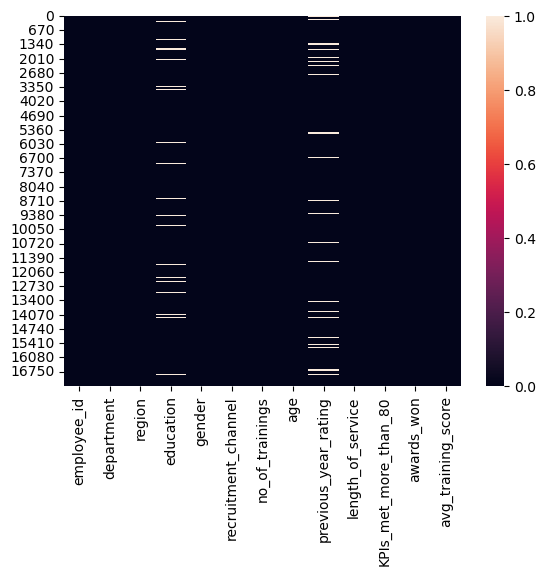

In [17]:
# Analyse des valeurs manquantes
print(df.isna().sum()/df.shape[0])
sns.heatmap(df.isna())

# les doublons

print(df.duplicated().sum())
df = df.drop_duplicates()
print(df.shape)

## Analyse de fond

C:\Users\JACQUES RAVEL\AppData\Local\Temp\ipykernel_4996\222499240.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col])


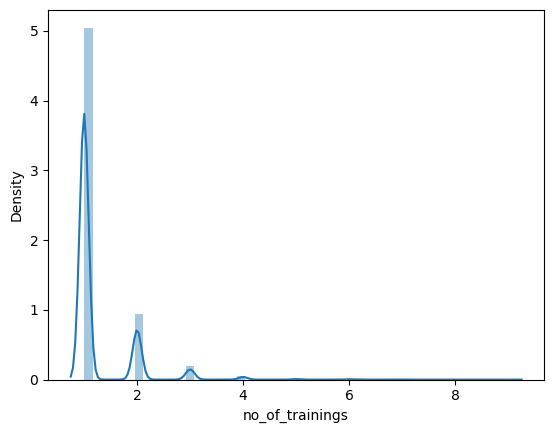

C:\Users\JACQUES RAVEL\AppData\Local\Temp\ipykernel_4996\222499240.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col])


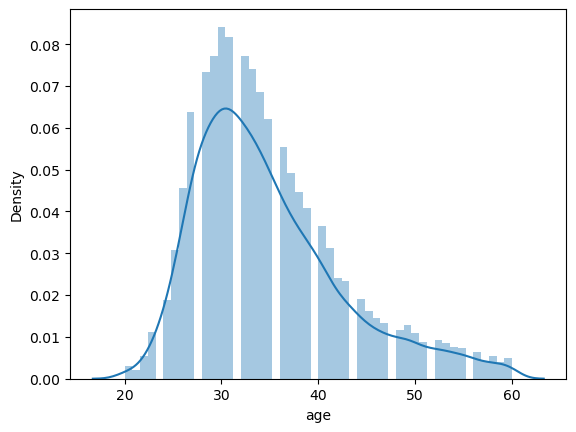

C:\Users\JACQUES RAVEL\AppData\Local\Temp\ipykernel_4996\222499240.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col])


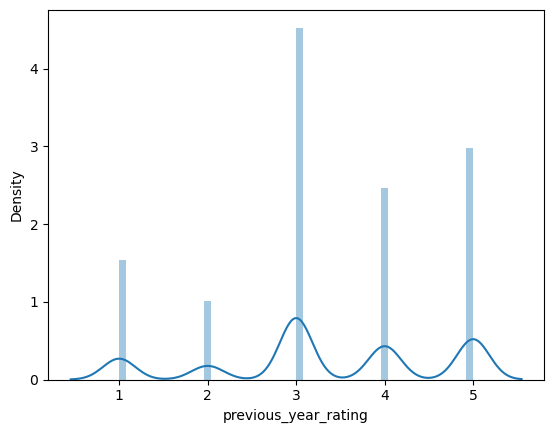

C:\Users\JACQUES RAVEL\AppData\Local\Temp\ipykernel_4996\222499240.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col])


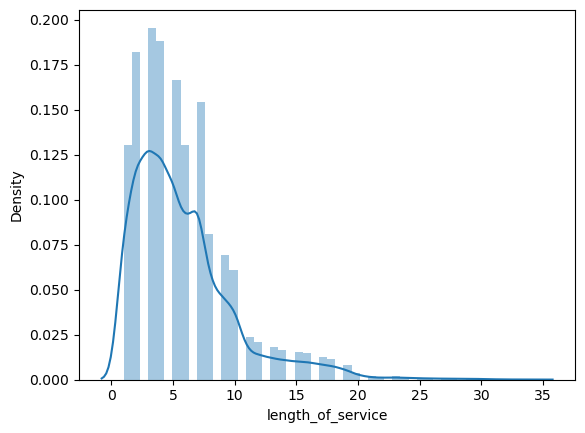

C:\Users\JACQUES RAVEL\AppData\Local\Temp\ipykernel_4996\222499240.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col])


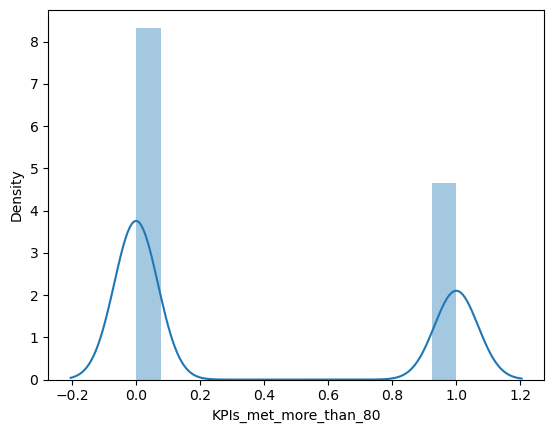

C:\Users\JACQUES RAVEL\AppData\Local\Temp\ipykernel_4996\222499240.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col])


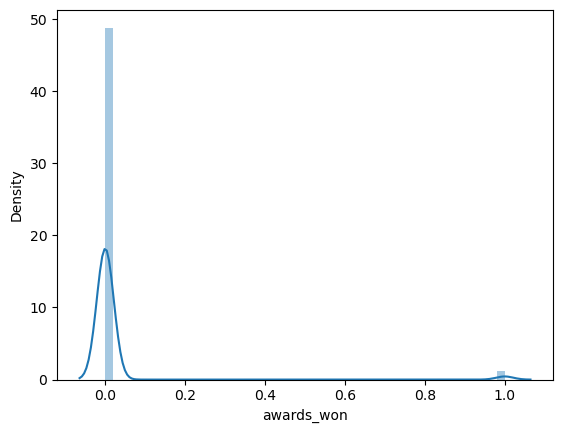

C:\Users\JACQUES RAVEL\AppData\Local\Temp\ipykernel_4996\222499240.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col])


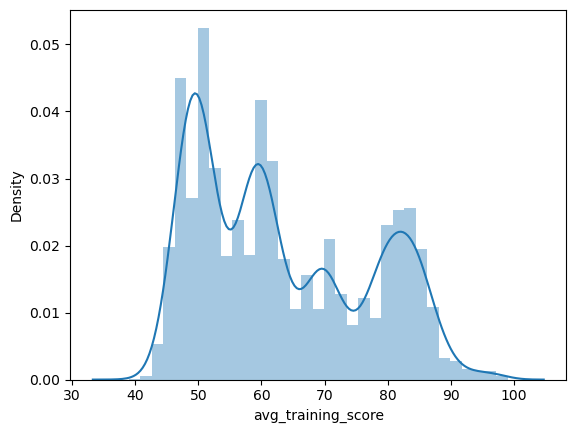

In [18]:
df = df.drop('employee_id', axis = 1)
# signification des variables
for col in df.select_dtypes(exclude = 'object'):
    plt.figure()
    sns.distplot(df[col])
    plt.show()

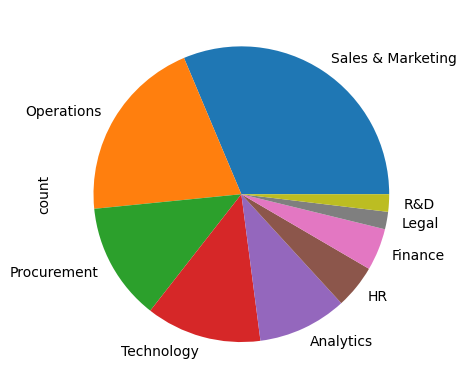

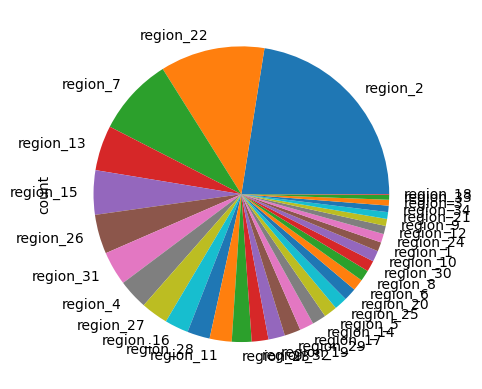

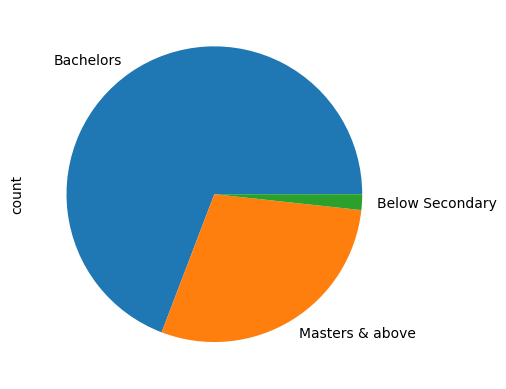

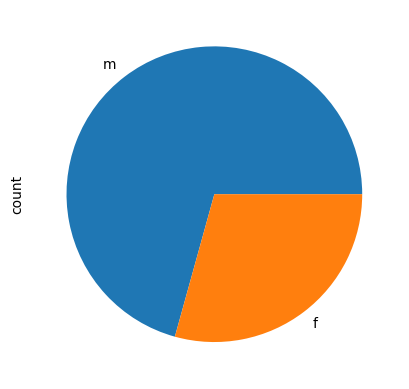

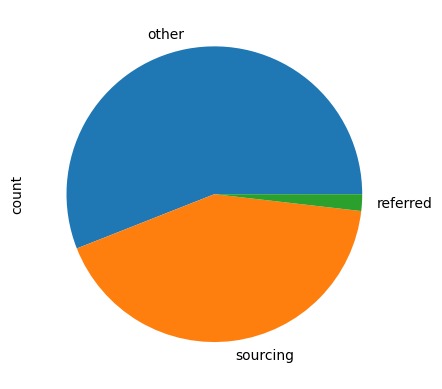

In [19]:
for col in df.select_dtypes(exclude = ['int', 'float']):
    plt.figure()
    df[col].value_counts().plot.pie()
    plt.show()

# segmentation

In [20]:
# comparaison des moyennes des notes selon les variables qualitatives
for col in df.select_dtypes(exclude = ['int', 'float']):
    print(df['avg_training_score'].groupby(df[col]).mean())

department
Analytics            84.565115
Finance              60.326683
HR                   50.386282
Legal                59.533133
Operations           60.351589
Procurement          70.180357
R&D                  84.451807
Sales & Marketing    50.056614
Technology           79.847658
Name: avg_training_score, dtype: float64
region
region_1     58.494253
region_10    65.808612
region_11    61.080952
region_12    57.769231
region_13    61.947674
region_14    61.094340
region_15    62.469751
region_16    61.130531
region_17    65.723881
region_18    49.785714
region_19    59.819048
region_2     63.131700
region_20    60.776860
region_21    62.782946
region_22    65.118593
region_23    63.103723
region_24    64.624242
region_25    60.822581
region_26    65.346257
region_27    63.788760
region_28    61.702326
region_29    66.055195
region_3     59.681818
region_30    62.129187
region_31    63.139319
region_32    62.408805
region_33    68.659341
region_34    64.926829
region_4     63.05

# conclusion

# Preprocessing

In [21]:
from sklearn.impute import KNNImputer, SimpleImputer
Imputer = KNNImputer(n_neighbors = 3)
Imputer1 = SimpleImputer(missing_values = np.nan, strategy = 'most_frequent')

df[['previous_year_rating']] = Imputer.fit_transform(df[['previous_year_rating']])
df[['education']] = Imputer1.fit_transform(df[['education']])

# lorsque on veut remplacer les valeurs manquantes dans pandas, chaque variable doit comprendre deux crochets!

# Comparaison des performances entre différents groupes

# 1. Comparaison des departements: Test anova

In [22]:
# creation des sous ensembles

Technology = df[df['department'] == 'Technology']
print(Technology.shape)
HR = df[df['department'] == 'HR']
print(HR.shape)
Sales_Marketing = df[df['department'] == 'Sales & Marketing']
print(Sales_Marketing.shape)
Procurement = df[df['department'] == 'Procurement']
print(Procurement.shape)
Finance = df[df['department'] == 'Finance']
print(Finance.shape)
Analytics = df[df['department'] == 'Analytics']
print(Analytics.shape)
Operations = df[df['department'] == 'Operations']
print(Operations.shape)
Legal = df[df['department'] == 'Legal']
print(Legal.shape)
R_D = df[df['department'] == 'R&D']
print(R_D.shape)

# redimensionnement des sous ensembles
Technology_balanced = Technology.sample(Legal.shape[0])
HR_balanced = HR.sample(Legal.shape[0])
Sales_Marketing_balanced = Sales_Marketing.sample(Legal.shape[0])
Procurement_balanced = Procurement.sample(Legal.shape[0])
Finance_balanced = Finance.sample(Legal.shape[0])
Analytics_balanced = Analytics.sample(Legal.shape[0])
Operations_balanced = Operations.sample(Legal.shape[0])

from scipy.stats import f_oneway

def anova1(col):
    p = 0.05
    
    f_stat, p_value = f_oneway(Technology_balanced[col].dropna(), HR_balanced[col].dropna(), 
                               Sales_Marketing_balanced[col].dropna(), Procurement_balanced[col].dropna(), 
                              Finance_balanced[col].dropna(), Analytics_balanced[col].dropna(), 
                              Operations_balanced[col].dropna(), Legal[col].dropna(), R_D[col].dropna())
    
    if p_value < p:
        return 'HO rejette'
    else:
        return 0
    
# le departement n'influence pas la performance

for col in df.select_dtypes(exclude = 'object'):
    print(f'{col:-<50} {anova1(col)}')

(2199, 12)
(831, 12)
(5458, 12)
(2240, 12)
(802, 12)
(1697, 12)
(3524, 12)
(332, 12)
(332, 12)
no_of_trainings----------------------------------- HO rejette
age----------------------------------------------- HO rejette
previous_year_rating------------------------------ HO rejette
length_of_service--------------------------------- HO rejette
KPIs_met_more_than_80----------------------------- HO rejette
awards_won---------------------------------------- 0
avg_training_score-------------------------------- HO rejette


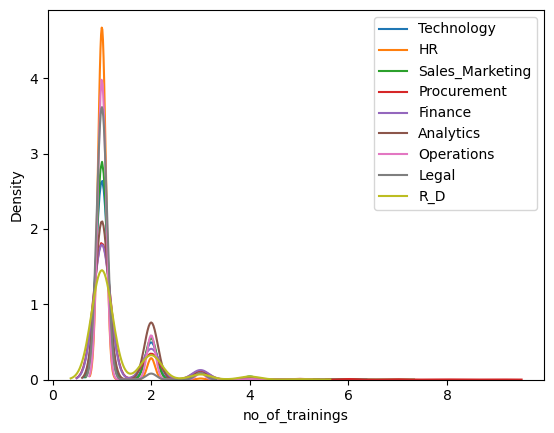

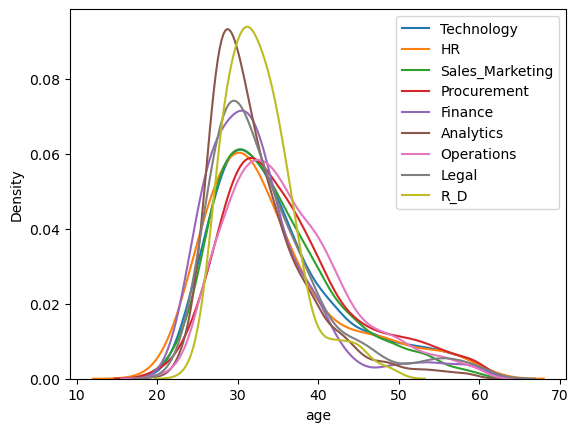

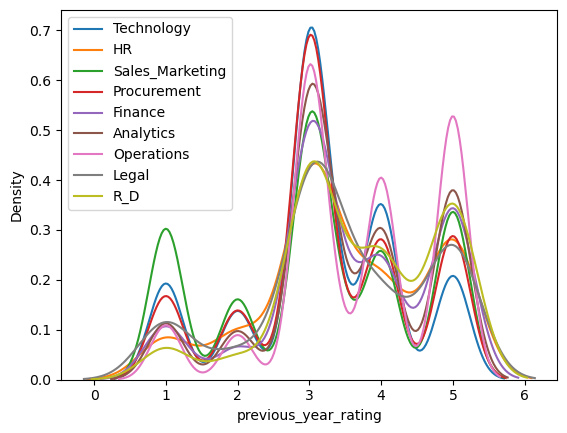

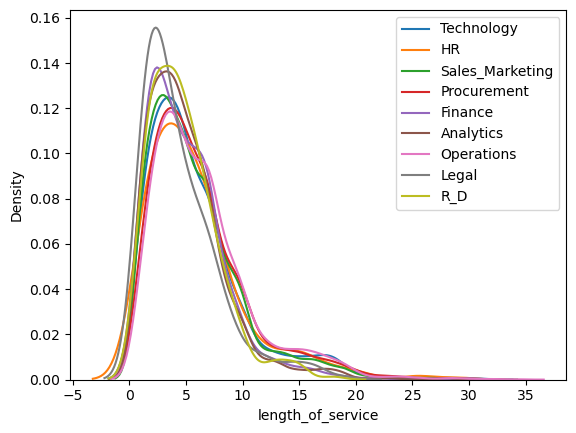

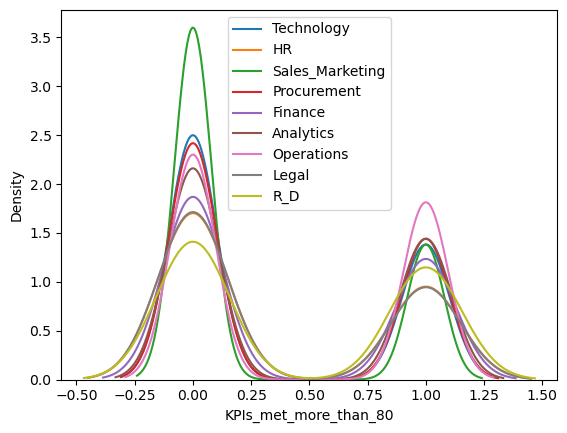

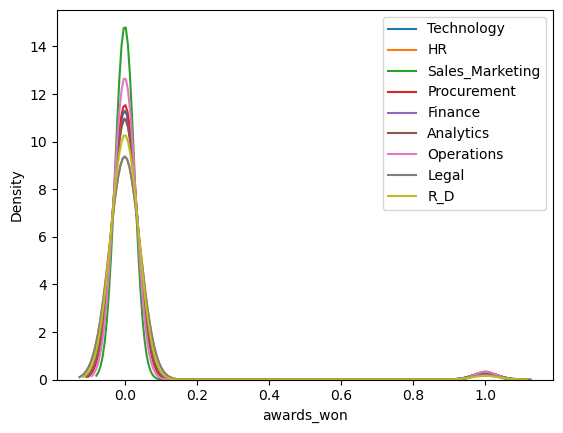

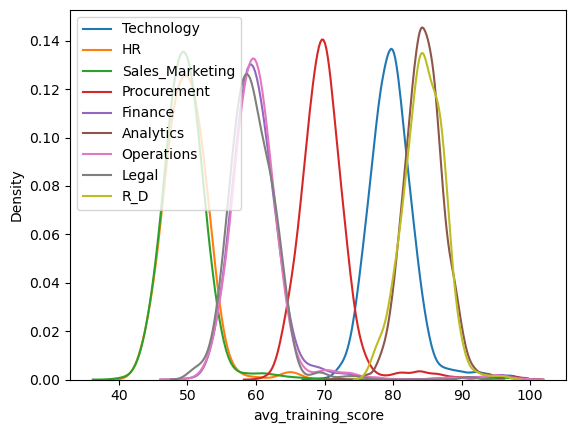

In [23]:
for col in df.select_dtypes(exclude = 'object'):
    plt.figure()
    sns.kdeplot(Technology[col], label = 'Technology')
    sns.kdeplot(HR_balanced[col], label = 'HR')
    sns.kdeplot(Sales_Marketing[col], label = 'Sales_Marketing')
    sns.kdeplot(Procurement[col], label = 'Procurement')
    sns.kdeplot(Finance[col], label = 'Finance')
    sns.kdeplot(Analytics[col], label = 'Analytics')
    sns.kdeplot(Operations[col], label = 'Operations')
    sns.kdeplot(Legal[col], label = 'Legal')
    sns.kdeplot(R_D[col], label = 'R_D')
    plt.legend()
    plt.show()

# Quel département a le plus besoin de formations?

# 2. Test de student sur le sexe

In [24]:
# Existe t-il une difference de performance entre les sexes?
# HO : les hommes et le femmes ont des niveaux de performances significativement differents

homme = df[df['gender'] == 'm']
femme = df[df['gender'] == 'f']

homme_balanced = homme.sample(femme.shape[0])
from scipy.stats import ttest_ind
def ttest(col):
    p = 0.05
    
    f_stat, p_value = ttest_ind(homme_balanced[col].dropna(), 
                                femme[col].dropna())
    
    if p_value < p:
        return 'HO rejette'
    else:
        return 0

# la conclusion est que peu importe le sexe, la performance n'en depend pas
for col in df.select_dtypes(exclude = 'object'):
    print(f'{col:-<50} {ttest(col)}')

no_of_trainings----------------------------------- HO rejette
age----------------------------------------------- 0
previous_year_rating------------------------------ HO rejette
length_of_service--------------------------------- 0
KPIs_met_more_than_80----------------------------- HO rejette
awards_won---------------------------------------- 0
avg_training_score-------------------------------- HO rejette


# Test post-hoc pour comparer les moyennes entre les groupes(sexe)

In [62]:
result = pairwise_tukeyhsd(endog = df['avg_training_score'], groups = df['gender'])
print(result)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     f      m  -0.7116 0.0014 -1.1493 -0.2738   True
----------------------------------------------------


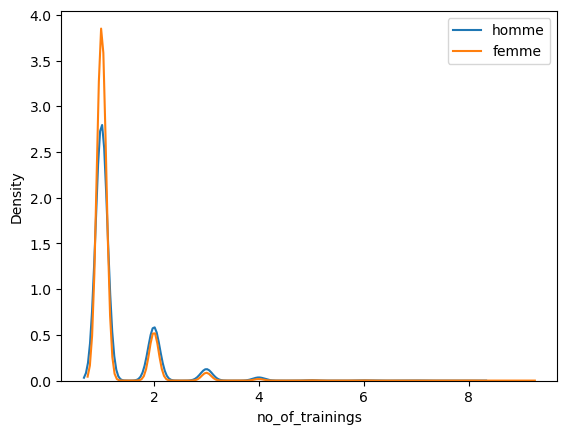

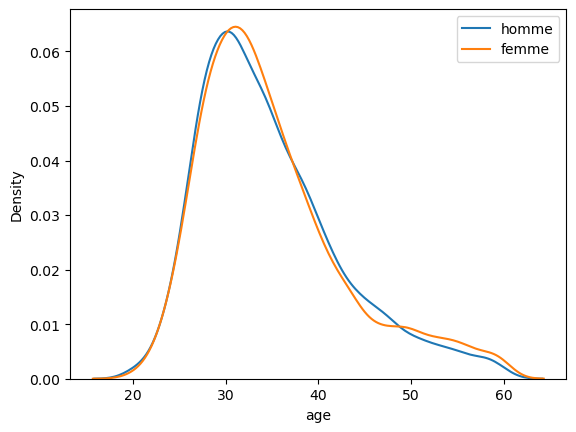

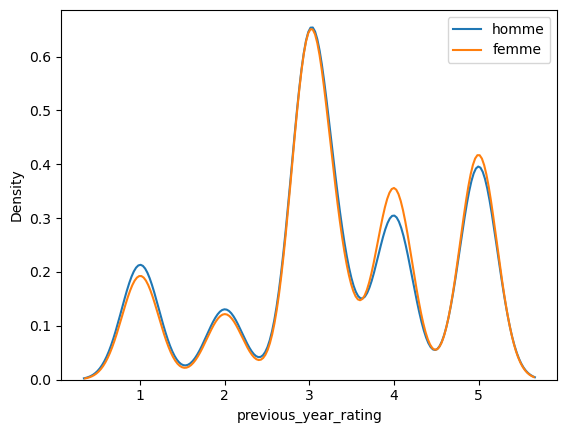

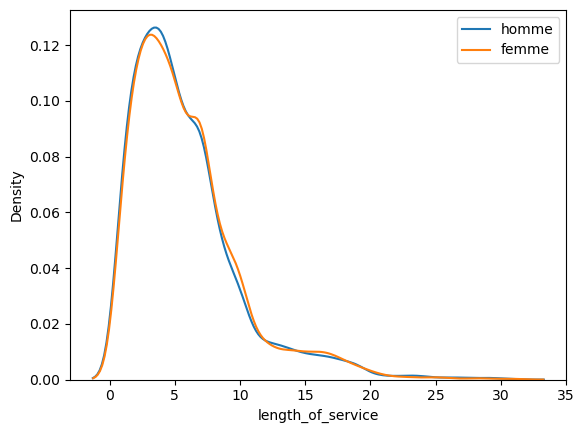

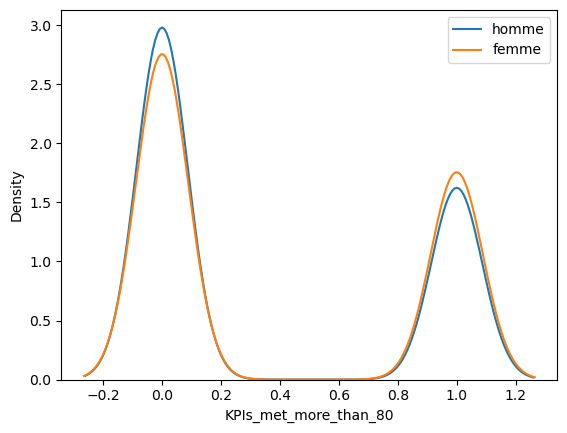

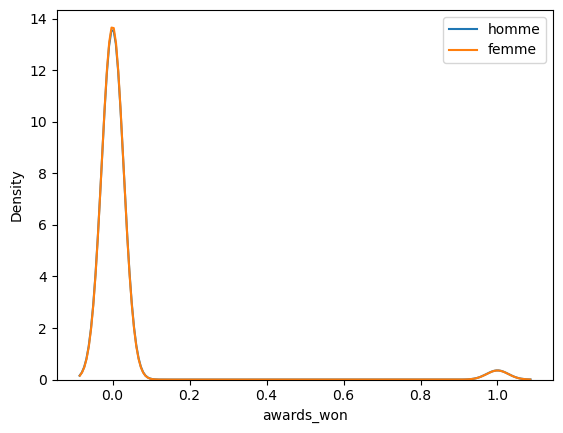

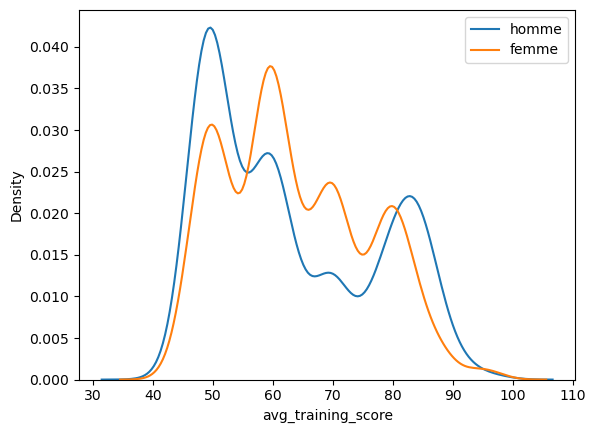

In [25]:
for col in df.select_dtypes(exclude = 'object'):
    plt.figure()
    sns.kdeplot(homme_balanced[col], label = 'homme')
    sns.kdeplot(femme[col], label = 'femme')
    plt.legend()
    plt.show()

# 3. Test anova sur niveau d'étude

In [26]:
# creation des sous ensembles
Bachelors = df[df['education'] == 'Bachelors']
Masters_above = df[df['education'] == 'Masters & above']
Below_Secondary = df[df['education'] == 'Below Secondary']

# redimensionnement des sous ensembles
Bachelors_balanced = Bachelors.sample(Below_Secondary.shape[0])
Masters_above_balanced = Masters_above.sample(Below_Secondary.shape[0])

def anova2(col):
    p = 0.05
    
    f_stat, p_value = f_oneway(Bachelors_balanced[col].dropna(), Masters_above_balanced[col].dropna(),
                              Below_Secondary[col].dropna())
    
    if p_value < p:
        return 'HO rejette'
    else:
        return 0
    
# le niveau d'etude n'influence pas la performance

for col in df.select_dtypes(exclude = 'object'):
    print(f'{col:-<50} {anova2(col)}')

no_of_trainings----------------------------------- 0
age----------------------------------------------- HO rejette
previous_year_rating------------------------------ 0
length_of_service--------------------------------- HO rejette
KPIs_met_more_than_80----------------------------- HO rejette
awards_won---------------------------------------- 0
avg_training_score-------------------------------- HO rejette


# Test post-hoc pour comparer les moyennes entre les groupes selon le niveau d'étude

In [60]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

result = pairwise_tukeyhsd(endog = df['avg_training_score'], groups = df['education'])
print(result) 

         Multiple Comparison of Means - Tukey HSD, FWER=0.05         
     group1          group2     meandiff p-adj   lower  upper  reject
---------------------------------------------------------------------
      Bachelors Below Secondary   3.1646 0.0002  1.2859 5.0433   True
      Bachelors Masters & above   1.3968    0.0  0.8638 1.9298   True
Below Secondary Masters & above  -1.7678 0.0768 -3.6791 0.1434  False
---------------------------------------------------------------------


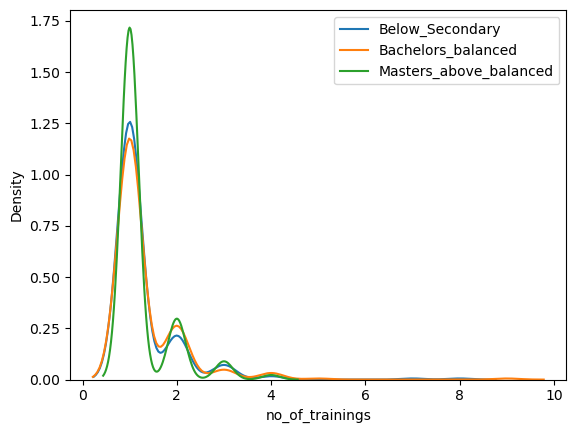

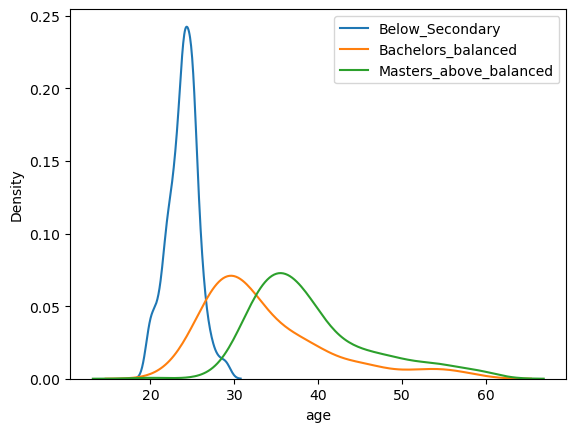

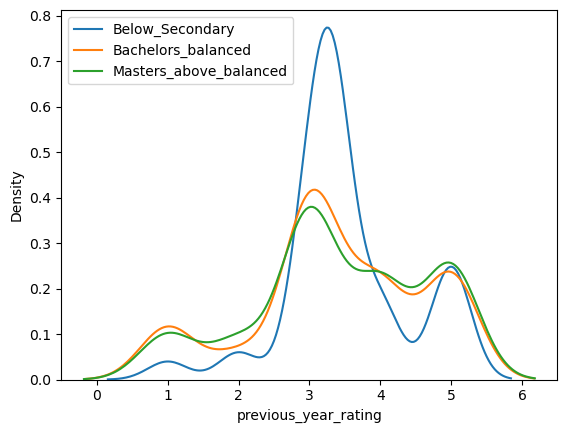

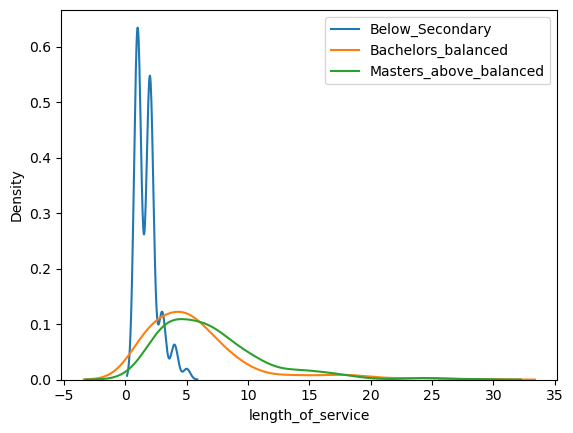

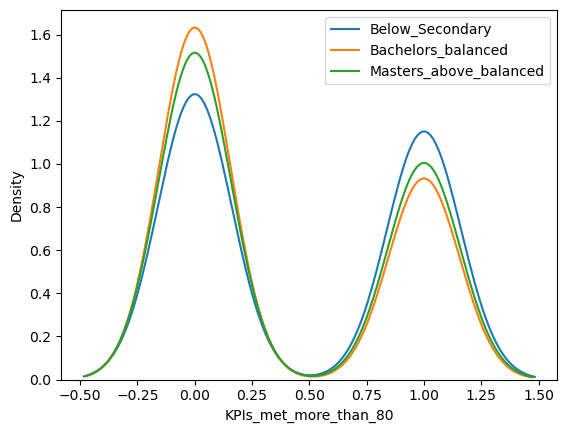

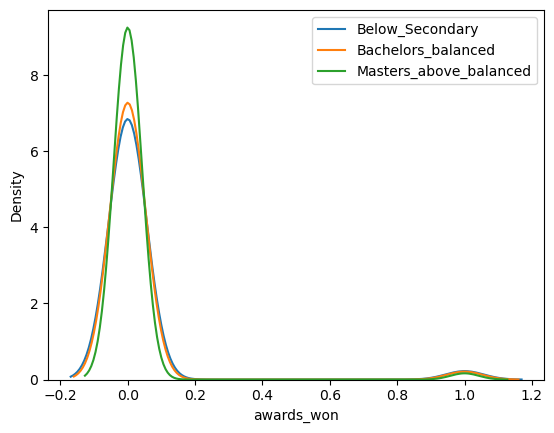

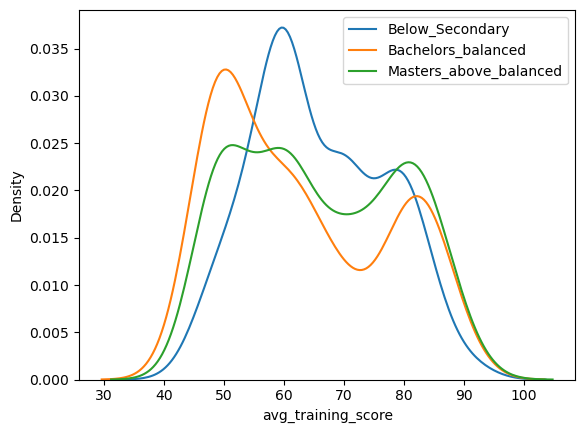

In [27]:
for col in df.select_dtypes(exclude = 'object'):
    plt.figure()
    sns.kdeplot(Below_Secondary[col], label = 'Below_Secondary')
    sns.kdeplot(Bachelors_balanced[col], label = 'Bachelors_balanced')
    sns.kdeplot(Masters_above_balanced[col], label = 'Masters_above_balanced')
    plt.legend()
    plt.show()

# 4. Test anova sur la voie de recrutement

In [54]:
# HO : les voies de recrutement donnent des performances significativement differents

print(df['recruitment_channel'].unique())
sourcing = df[df['recruitment_channel'] == 'sourcing']
other = df[df['recruitment_channel'] == 'other']
referred = df[df['recruitment_channel'] == 'referred']
print(sourcing.shape)
print(other.shape)
print(referred.shape)

# redimensionnement de sourcing et other
sourcing_balanced = sourcing.sample(referred.shape[0])
print(sourcing_balanced.shape)
other_balanced = other.sample(referred.shape[0])
print(other_balanced.shape)

# test d'anova
from scipy.stats import f_oneway

def anova3(col):
    p = 0.05
    
    f_stat, p_value = f_oneway(sourcing_balanced[col].dropna(), other_balanced[col].dropna(), 
                               referred[col].dropna())
    
    if p_value < p:
        return 'HO rejette'
    else:
        return 0

for col in df.select_dtypes(exclude = 'object'):
    print(f'{col:-<50} {anova3(col)}')

['sourcing' 'other' 'referred']
(7349, 12)
(9749, 12)
(317, 12)
(317, 12)
(317, 12)
no_of_trainings----------------------------------- HO rejette
age----------------------------------------------- HO rejette
previous_year_rating------------------------------ HO rejette
length_of_service--------------------------------- 0
KPIs_met_more_than_80----------------------------- HO rejette
awards_won---------------------------------------- 0
avg_training_score-------------------------------- 0


# Test post-hoc pour comparer les moyennes entre les groupes selon les voies de recrutement

In [61]:
from scipy.stats import tukey_hsd

result = pairwise_tukeyhsd(endog = df['avg_training_score'], groups = df['recruitment_channel'])

print(result)    

  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
 group1   group2  meandiff p-adj   lower   upper  reject
--------------------------------------------------------
   other referred   1.1014 0.3211 -0.6931  2.8959  False
   other sourcing  -0.5897 0.0123 -1.0754 -0.1039   True
referred sourcing   -1.691 0.0716 -3.4947  0.1127  False
--------------------------------------------------------


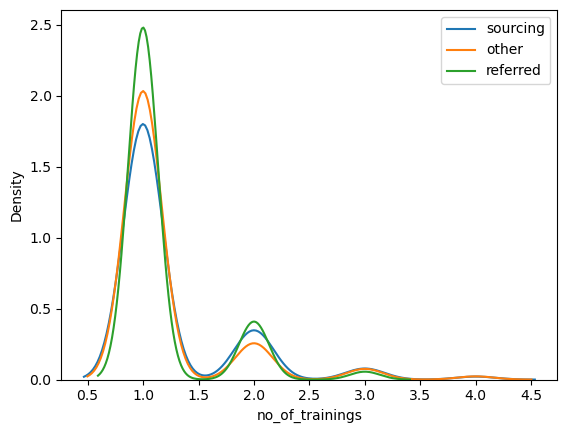

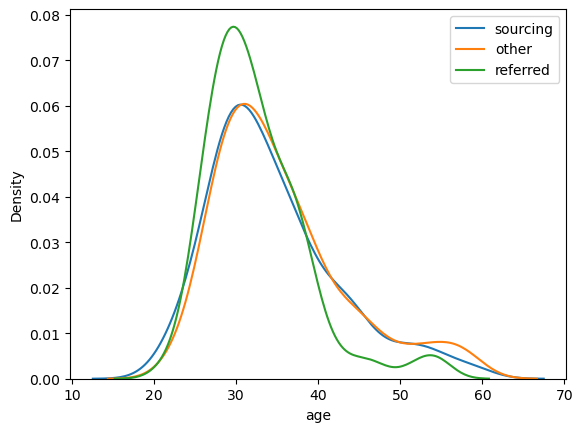

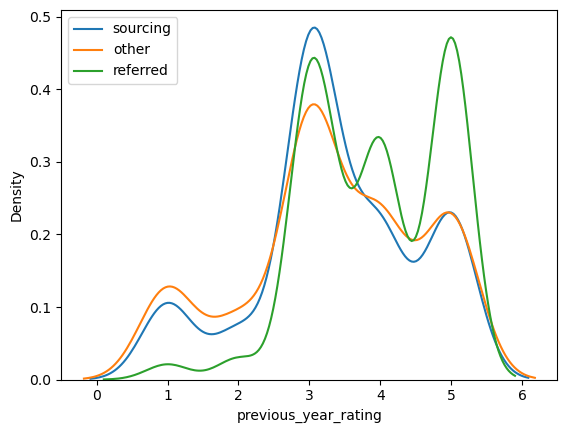

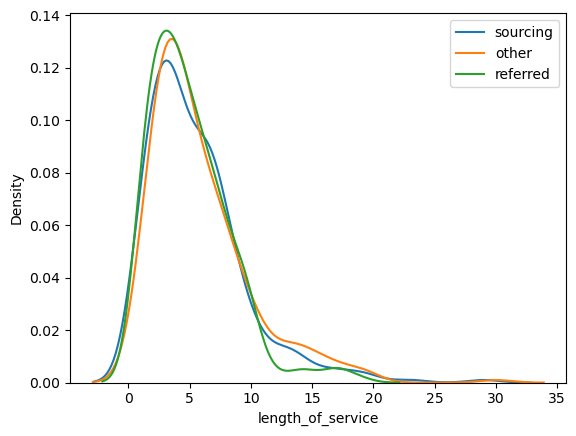

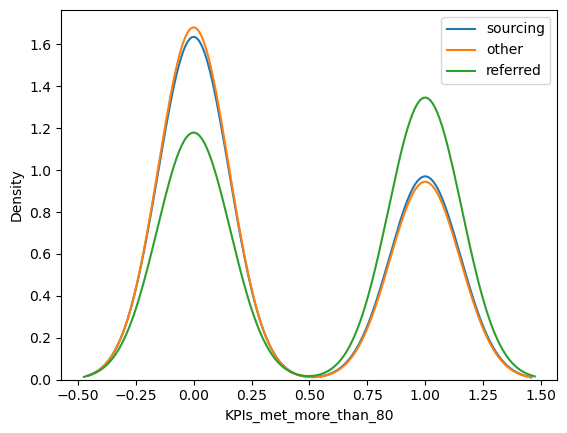

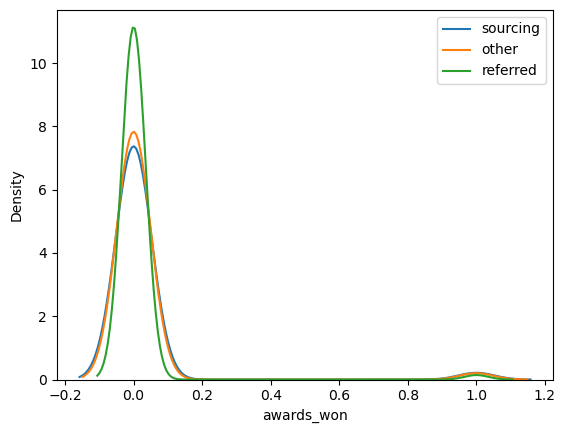

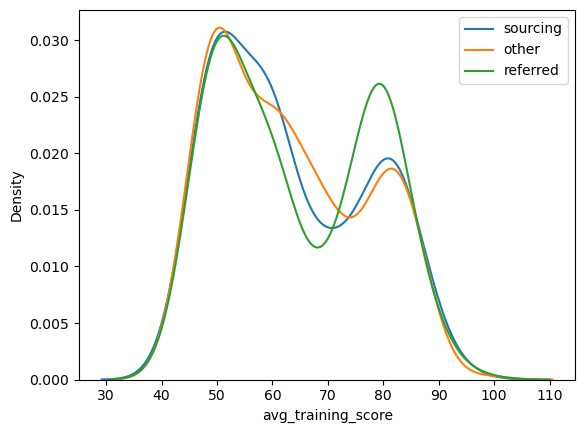

In [30]:
for col in df.select_dtypes(exclude = 'object'):
    plt.figure()
    sns.kdeplot(sourcing_balanced[col], label = 'sourcing')
    sns.kdeplot(other_balanced[col], label = 'other')
    sns.kdeplot(referred[col], label = 'referred')
    plt.legend()
    plt.show()

# Test d'indépendance entre les variables qualitatives: Test de chi2

In [31]:
# H0 : les deux variables sont dependants
# H1 : les deux variables ne sont pas dependants(independants)
from scipy.stats import chi2_contingency
for col in df.select_dtypes(exclude = ['int', 'float']):
    p = 0.05
    table = pd.crosstab(df['department'], df[col])
    
    chi2, p_value, ddl, expected = chi2_contingency(table)
    
    if p_value < p:
        print(f'{col:-<50} H0 rejete')
    else:
        print(f'{col:-<50} H0 accepte')

department---------------------------------------- H0 rejete
region-------------------------------------------- H0 rejete
education----------------------------------------- H0 rejete
gender-------------------------------------------- H0 rejete
recruitment_channel------------------------------- H0 rejete


# Correlation entre les variables

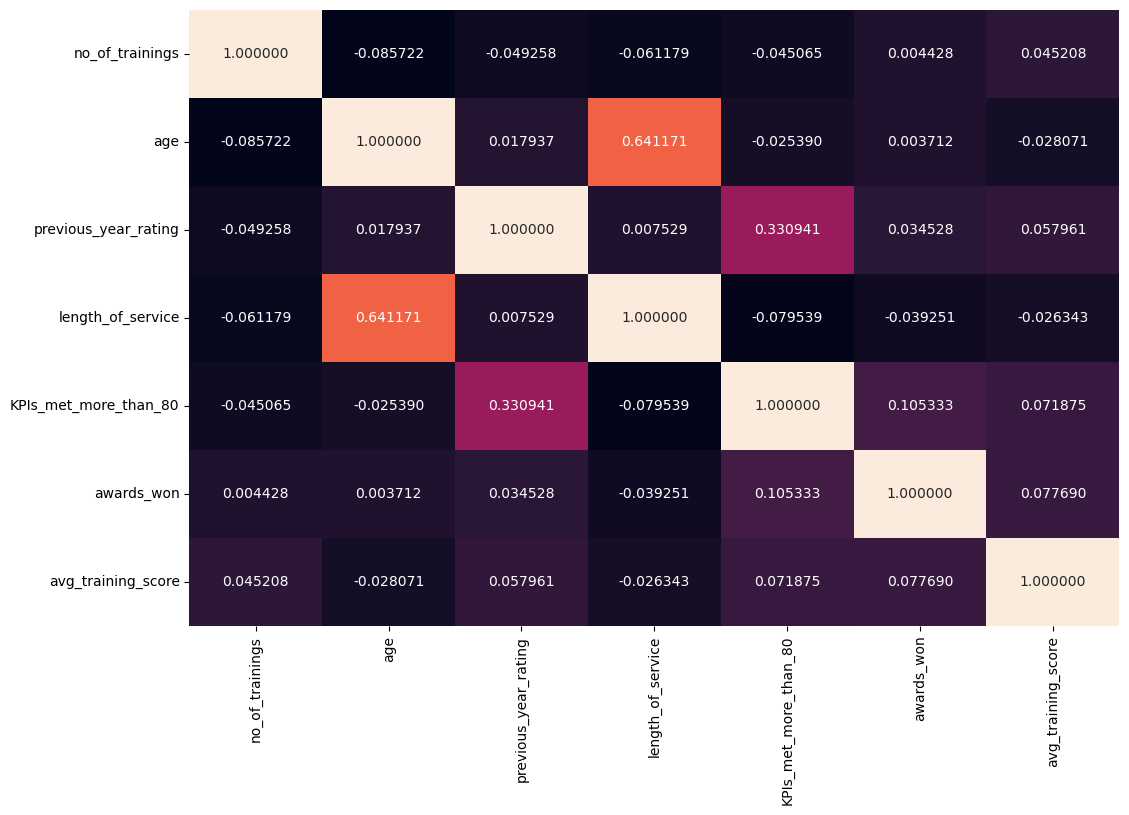

In [32]:
plt.figure(figsize = (12, 8))
sns.heatmap(df.select_dtypes(exclude = 'object').corr(), annot = True, fmt = 'f', cbar = False)
plt.show()

# Recommandations